# Complex Crochet Scheme Generation — Router Agent

**Goal.** Extend the Crochet pipeline so that a single natural-language prompt
can produce either (a) a flat 2D crochet scheme, or (b) a 3D amigurumi
pattern for objects that cannot be represented as a flat diagram (e.g. hats,
toys, clothing). A small router, built on **ModernBERT** zero-shot
classification and wired into **LangChain**, decides which path to take.

This notebook is a research + runnable demo. It degrades gracefully: every
optional dependency (LangChain, HF transformers, Gemini, Hunyuan3D) has a
mock fallback so you can step through the full pipeline end-to-end on a
CPU-only machine with no API keys.

---

## Research summary

| Topic | Finding | Source |
|---|---|---|
| **3D -> crochet (academic)** | *AmiGo* (SIGGRAPH Asia 2022): closed triangle mesh + seed point + stitch size -> human-readable `sc / inc / dec` instructions. Works by computing saddle points of a geodesic distance function, slicing isolines into rings, and segmenting the mesh into crochetable components joined via join-as-you-go. | [arxiv 2211.01178](https://arxiv.org/abs/2211.01178) / [ACM](https://dl.acm.org/doi/fullHtml/10.1145/3559400.3562005) |
| **3D -> crochet (platform)** | *CrochetPARADE* is a browser platform for 2D and 3D crochet, including a Remesher that turns meshes into instructions. Its DSL is what `crochet.dsl` already targets. | [CrochetPARADE](https://www.crochetparade.org/) / [GitHub](https://github.com/crochetparade/CrochetPARADE) |
| **Stitch mesh** | Automatic pipeline that converts a manifold triangulated mesh into a *stitch mesh* of quads (sc / turn), pentagons (sc2tog) and increase-triangles (inc). | [ACM](https://dl.acm.org/doi/fullHtml/10.1145/3424630.3425409) |
| **Knitting precedent** | Carnegie Mellon has an autoknit compiler that solves the same problem for machine-knit stuffed toys, confirming the slice-into-rings-then-emit-increases recipe works. | [Hackaday](https://hackaday.com/2019/06/14/knitting-software-automatically-converts-3d-models-into-machine-knit-stuffies/) |
| **Text -> 3D** | *Hunyuan3D 2.x* (Tencent, Jan 2025) is the current best open-weights text-to-3D / image-to-3D model; the HF Space exposes a UI and an endpoint callable with `gradio_client`. *TripoSR* is faster (<=5 s) but lower fidelity. | [HF Space](https://huggingface.co/spaces/tencent/Hunyuan3D-2) / [GitHub](https://github.com/Tencent-Hunyuan/Hunyuan3D-2) / [TripoSR](https://huggingface.co/spaces/hansyan/perflow-triposr) |
| **ModernBERT zero-shot** | `MoritzLaurer/ModernBERT-large-zeroshot-v2.0` and the GLiClass ModernBERT variants do zero-shot classification with 8K context, fast on CPU. | [HF blog](https://huggingface.co/blog/Ihor/refreshing-zero-shot-classification) / [ClassyText demo](https://github.com/sitamgithub-MSIT/ClassyText) |
| **LangChain routing** | The *router* pattern classifies input then hands off to one of several specialised agents - exactly what we need for 2D-vs-3D dispatch. | [LangChain docs](https://docs.langchain.com/oss/python/langchain/multi-agent/router) |
| **Mesh slicing** | `trimesh.Trimesh.section_multiplane` takes parallel cross-sections at any pitch along an axis and returns 2D paths - direct input to an amigurumi row generator. | [trimesh section docs](https://trimesh.org/section.html) |

**Design decision.** We do not reimplement AmiGo in full. Instead we
implement the practical subset that covers the majority of amigurumi shapes:

1. Text/image -> 3D mesh (Hunyuan3D; mock fallback = a torus).
2. Mesh -> horizontal ring slices at one-stitch pitch (`trimesh`).
3. Ring circumferences -> stitch counts (using a configurable stitches-per-cm
   gauge); the row-over-row delta becomes `inc` or `dec` operations.
4. As a complementary output, render the mesh from several viewpoints and
   run the existing YOLO-OBB scheme parser on each projection - useful when
   the object is mostly flat (blanket, tapestry) or when the user wants a
   traditional stitch chart alongside the amigurumi row instructions.

## Architecture

```
             +------------------------------+
  prompt --> |  ModernBERT zero-shot        |
             |  ["2d_scheme", "3d_object"]  |
             +----------------+-------------+
                              |
             +----------------+----------------+
             |                                 |
             v                                 v
  +--------------------+       +-----------------------------+
  |  2D path           |       |  3D path                    |
  |  Gemini -> YOLO    |       |  Hunyuan3D -> mesh          |
  |  OBB -> rendering  |       |    - multi-view -> YOLO     |
  +--------------------+       |    - ring slicer -> ami DSL |
                               +-----------------------------+
```

## 0 - Setup

Uncomment the `pip install` cell below on first run. All imports are guarded
so missing deps trigger a mock path rather than a hard failure.

In [115]:
%pip install -q trimesh langchain langchain-core transformers \
                gradio_client Pillow matplotlib numpy opencv-python \
                ultralytics google-genai

Note: you may need to restart the kernel to use updated packages.


In [116]:
from __future__ import annotations

import os, sys, json, math, time, textwrap, dataclasses, importlib
from pathlib import Path
from typing import Any, Callable, Literal

# Make the sibling `crochet` package importable from this notebook.
REPO_ROOT = Path.cwd().resolve()
if (REPO_ROOT / "crochet").is_dir():
    pass
elif (REPO_ROOT.parent / "crochet").is_dir():
    REPO_ROOT = REPO_ROOT.parent
else:
    raise RuntimeError("Could not locate the `crochet` package next to this notebook.")
sys.path.insert(0, str(REPO_ROOT))

# Load .env so GEMINI_API_KEY / GOOGLE_API_KEY / HF_TOKEN etc. are visible to
# downstream libraries (google-genai, gradio_client). Python does NOT auto-read
# .env; we parse it ourselves to avoid adding a python-dotenv dependency.
# We check the notebooks folder first, then the repo root.
def _load_dotenv() -> Path | None:
    for candidate in (REPO_ROOT / "notebooks" / ".env", REPO_ROOT / ".env"):
        if candidate.is_file():
            for raw in candidate.read_text().splitlines():
                line = raw.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, _, value = line.partition("=")
                key = key.strip()
                value = value.strip().strip('"').strip("'")
                if key and key not in os.environ:
                    os.environ[key] = value
            return candidate
    return None

_ENV_PATH = _load_dotenv()

import numpy as np
import matplotlib.pyplot as plt

# Reload all already-imported crochet.* modules so re-running this cell
# after editing `crochet/config.py` (or any other crochet module) picks up
# the new values without needing a kernel restart. Function default args
# such as `classify_stitches(weights_path=DEFAULT_WEIGHTS)` are baked in at
# import time, so a reload is required.
for _name in [m for m in list(sys.modules) if m == "crochet" or m.startswith("crochet.")]:
    try:
        importlib.reload(sys.modules[_name])
    except Exception:
        pass


def _have(mod: str) -> bool:
    try:
        importlib.import_module(mod); return True
    except Exception:
        return False

HAS_TRANSFORMERS  = _have("transformers")
HAS_LANGCHAIN     = _have("langchain_core")
HAS_TRIMESH       = _have("trimesh")
HAS_GENAI         = _have("google.genai")
HAS_GRADIO_CLIENT = _have("gradio_client")
HAS_ULTRALYTICS   = _have("ultralytics")

_has_key = bool(os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY"))

print(f"repo root         : {REPO_ROOT}")
print(f".env loaded       : {_ENV_PATH}")
print(f"GEMINI_API_KEY    : {'set' if _has_key else 'MISSING'}")
print(f"transformers      : {HAS_TRANSFORMERS}")
print(f"langchain-core    : {HAS_LANGCHAIN}")
print(f"trimesh           : {HAS_TRIMESH}")
print(f"google-genai      : {HAS_GENAI}")
print(f"gradio_client     : {HAS_GRADIO_CLIENT}")
print(f"ultralytics       : {HAS_ULTRALYTICS}")

repo root         : /Users/elevchenko/Documents/DataScience/Crochet
.env loaded       : /Users/elevchenko/Documents/DataScience/Crochet/notebooks/.env
GEMINI_API_KEY    : set
transformers      : True
langchain-core    : True
trimesh           : True
google-genai      : True
gradio_client     : True
ultralytics       : True


## 1 - ModernBERT zero-shot classifier

Two candidate labels: `2d_scheme` and `3d_object`. We use
[`MoritzLaurer/ModernBERT-large-zeroshot-v2.0`](https://huggingface.co/MoritzLaurer/ModernBERT-large-zeroshot-v2.0)
via HF's `pipeline("zero-shot-classification", ...)`. The first call
downloads the weights (~390 MB); subsequent calls are cached.

If `transformers` is not available we fall back to a keyword rule so the
rest of the notebook still runs.

In [117]:
ZSC_LABELS = {
    "2d_scheme": "A flat crochet chart or motif drawn on paper - a symbol diagram readable as a single image (granny square, doily, lace motif, stitch chart).",
    "3d_object": "A physical three-dimensional crocheted object that cannot be represented by a single flat image - a toy, amigurumi, hat, bag, sweater, sock, shoe, or any wearable garment.",
}


def _classify_rule_based(prompt: str) -> tuple[str, dict[str, float]]:
    '''Keyword-based fallback when `transformers` is not installed.'''
    p = prompt.lower()
    td = ["hat", "beanie", "sock", "shoe", "boot", "sweater", "cardigan",
          "scarf", "bag", "purse", "doll", "toy", "amigurumi", "plush",
          "dress", "skirt", "mitten", "glove", "slipper", "blanket"]
    flat = ["chart", "motif", "diagram", "scheme", "granny square",
            "doily", "lace", "mandala", "coaster", "placemat"]
    s3d = sum(1 for w in td if w in p)
    s2d = sum(1 for w in flat if w in p)
    if s3d == 0 and s2d == 0:
        scores = {"2d_scheme": 0.55, "3d_object": 0.45}
    elif s3d >= s2d:
        conf = 0.55 + 0.1 * min(s3d, 4)
        scores = {"3d_object": conf, "2d_scheme": 1 - conf}
    else:
        conf = 0.55 + 0.1 * min(s2d, 4)
        scores = {"2d_scheme": conf, "3d_object": 1 - conf}
    winner = max(scores, key=scores.get)
    return winner, scores


_zsc_pipe = None
def classify_prompt(prompt: str) -> tuple[str, dict[str, float]]:
    '''Return (label, {label: score}) for a user prompt.'''
    global _zsc_pipe
    if not HAS_TRANSFORMERS:
        return _classify_rule_based(prompt)
    if _zsc_pipe is None:
        from transformers import pipeline
        _zsc_pipe = pipeline(
            "zero-shot-classification",
            model="MoritzLaurer/ModernBERT-large-zeroshot-v2.0",
        )
    labels = list(ZSC_LABELS.keys())
    descriptions = [ZSC_LABELS[l] for l in labels]
    out = _zsc_pipe(prompt,
                    candidate_labels=descriptions,
                    hypothesis_template="This text is asking for {}.",
                    multi_label=False)
    desc_to_label = {ZSC_LABELS[l]: l for l in labels}
    scores = {desc_to_label[d]: float(s) for d, s in zip(out["labels"], out["scores"])}
    winner = max(scores, key=scores.get)
    return winner, scores

In [118]:
examples = [
    "Generate a granny-square scheme with fans in the corners",
    "Make me a crochet pattern for a fluffy teddy bear, about 20 cm tall",
    "I need a lace doily chart with an 8-pointed star",
    "Design a slouchy beanie for an adult",
    "A cute octopus amigurumi plushie",
    "Mandala-style circular crochet diagram with treble stitches",
]
for e in examples:
    label, scores = classify_prompt(e)
    top = ", ".join(f"{k}={v:.2f}" for k, v in sorted(scores.items(), key=lambda kv:-kv[1]))
    print(f"[{label:<10}] {top:<35}  {e}")

Loading weights: 100%|██████████| 174/174 [00:00<00:00, 5231.34it/s]


[2d_scheme ] 2d_scheme=0.90, 3d_object=0.10       Generate a granny-square scheme with fans in the corners
[3d_object ] 3d_object=0.90, 2d_scheme=0.10       Make me a crochet pattern for a fluffy teddy bear, about 20 cm tall
[2d_scheme ] 2d_scheme=0.80, 3d_object=0.20       I need a lace doily chart with an 8-pointed star
[3d_object ] 3d_object=0.92, 2d_scheme=0.08       Design a slouchy beanie for an adult
[3d_object ] 3d_object=0.80, 2d_scheme=0.20       A cute octopus amigurumi plushie
[3d_object ] 3d_object=0.55, 2d_scheme=0.45       Mandala-style circular crochet diagram with treble stitches


## 2 - LangChain router

LangChain's router composes a classifier with N downstream runnables. We
wrap `classify_prompt` as a `RunnableLambda` and route to one of two agent
runnables using `RunnableBranch`.

If `langchain-core` is not installed the router degrades to a plain Python
dispatch - the shape of the API stays the same so nothing downstream needs
to change.

In [119]:
@dataclasses.dataclass
class RouteDecision:
    label: Literal["2d_scheme", "3d_object"]
    scores: dict[str, float]
    prompt: str


def _decide(inp: dict) -> RouteDecision:
    prompt = inp["prompt"]
    label, scores = classify_prompt(prompt)
    return RouteDecision(label=label, scores=scores, prompt=prompt)


def build_router(agent_2d: Callable, agent_3d: Callable):
    '''Build a prompt -> final-payload runnable.

    `agent_2d` and `agent_3d` are plain callables `(RouteDecision) -> dict`.
    '''
    if HAS_LANGCHAIN:
        from langchain_core.runnables import RunnableBranch, RunnableLambda
        decide = RunnableLambda(_decide)
        branch = RunnableBranch(
            (lambda d: d.label == "3d_object", RunnableLambda(agent_3d)),
            RunnableLambda(agent_2d),  # default
        )
        return decide | branch

    class _Pipe:
        def invoke(self, inp):
            decision = _decide(inp)
            return (agent_3d if decision.label == "3d_object" else agent_2d)(decision)
    return _Pipe()

## 3 - 2D path: Gemini image -> YOLO OBB -> scheme

This wraps the existing `crochet.pipeline.classify_stitches` so the router
gets a single callable. Missing Gemini key or weights -> we synthesise a
placeholder scheme so the notebook still flows.

In [120]:
# Reload crochet.config in case it was edited since the last cell's reload
# loop ran; this guarantees DEFAULT_WEIGHTS below is the latest value.
import crochet.config as _ccfg
importlib.reload(_ccfg)
from crochet.config import DEFAULT_WEIGHTS
from crochet.generation import DEFAULT_PROMPT as GEMINI_DEFAULT_PROMPT


def _resolve_weights(path_str: str) -> Path:
    '''Resolve DEFAULT_WEIGHTS to an absolute path.

    Accepts absolute paths, `~`-prefixed paths, and repo-relative paths.
    Returns the absolute Path even if the file does not exist so callers
    can print a useful error.
    '''
    p = Path(os.path.expanduser(path_str))
    if not p.is_absolute():
        p = (REPO_ROOT / p).resolve()
    return p


WEIGHTS_PATH = _resolve_weights(DEFAULT_WEIGHTS)
WEIGHTS_EXIST = WEIGHTS_PATH.is_file()
HAS_GEMINI_KEY = bool(os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY"))

print(f"weights path   : {WEIGHTS_PATH}")
print(f"weights exist  : {WEIGHTS_EXIST}")


def _mock_scheme_image(w: int = 512, h: int = 512) -> np.ndarray:
    '''Simple circular dummy scheme for smoke-testing the pipeline.'''
    img = np.full((h, w, 3), 255, dtype=np.uint8)
    cx, cy = w // 2, h // 2
    for r in range(40, min(cx, cy), 40):
        for theta in np.linspace(0, 2 * np.pi, int(2 * np.pi * r / 25), endpoint=False):
            x = int(cx + r * np.cos(theta)); y = int(cy + r * np.sin(theta))
            img[y - 4:y + 4, x - 1:x + 1] = 0
            img[y - 1:y + 1, x - 4:x + 4] = 0
    return img


def agent_2d(decision: RouteDecision) -> dict:
    out: dict[str, Any] = {"path": "2d", "prompt": decision.prompt,
                           "scores": decision.scores}
    out_png = REPO_ROOT / "notebooks_output" / "generated_2d.png"
    out_png.parent.mkdir(exist_ok=True)

    if HAS_GENAI and HAS_GEMINI_KEY:
        from crochet.generation import generate_image
        generate_image(prompt=decision.prompt, output_path=out_png)
        out["image_path"] = str(out_png)
    else:
        import cv2 as cv
        img = _mock_scheme_image()
        cv.imwrite(str(out_png), img)
        out["image_path"] = str(out_png)
        out["note"] = "Gemini unavailable - used mock scheme image."

    if HAS_ULTRALYTICS and WEIGHTS_EXIST:
        from crochet.pipeline import classify_stitches
        # Pass `weights_path` explicitly — the default baked into
        # classify_stitches at import time may be stale if `crochet.config`
        # was edited after the module was first loaded.
        summary = classify_stitches(
            image_path=out_png,
            weights_path=str(WEIGHTS_PATH),
            visualize_tiles=False,
            output_figure=out_png.with_name(out_png.stem + "_predictions.png"),
        )
        out["num_detections"] = summary["num_detections"]
        out["figure_path"] = str(summary["figure_path"])
    else:
        out["num_detections"] = None
        out["note"] = (out.get("note", "") + " | "
                       "YOLO skipped (weights or ultralytics missing).").lstrip(" |")
    return out

weights path   : /Users/elevchenko/Documents/DataScience/Crochet/runs/obb/obb_train23/weights/best.pt
weights exist  : True


## 4 - 3D path: text -> mesh

### 4.1 Primary backend: Hunyuan3D via `gradio_client`

`gradio_client` lets us call the public HF Space programmatically:

```python
from gradio_client import Client
client = Client("tencent/Hunyuan3D-2")
glb_path = client.predict(prompt, api_name="/text_to_3d")  # returns a .glb
```

The Space is rate-limited and occasionally queued, so we wrap the call in a
try/except and fall back to a deterministic demo mesh (a torus for
hat/beanie prompts, a sphere for anything else) so the rest of the pipeline
always has something to work with.

In [121]:
def _demo_mesh_for_prompt(prompt: str):
    import trimesh
    p = prompt.lower()
    if any(w in p for w in ("hat", "beanie", "cap")):
        return trimesh.creation.annulus(r_min=9.0, r_max=10.0, height=12.0, sections=64)
    if any(w in p for w in ("bag", "basket", "bowl")):
        return trimesh.creation.cylinder(radius=10.0, height=18.0, sections=64)
    if "scarf" in p or "blanket" in p:
        return trimesh.creation.box(extents=(50.0, 15.0, 0.5))
    # Default: an amigurumi-sized sphere (~12 cm diameter).
    return trimesh.creation.icosphere(subdivisions=4, radius=6.0)


_HUNYUAN_CLIENT = None           # cache the client across calls
_HUNYUAN_API_PRINTED = False     # only dump view_api() once


def _hunyuan_client():
    """Lazily build (and cache) a gradio_client.Client for Hunyuan3D-2."""
    global _HUNYUAN_CLIENT
    if _HUNYUAN_CLIENT is None:
        from gradio_client import Client
        _HUNYUAN_CLIENT = Client("tencent/Hunyuan3D-2")
    return _HUNYUAN_CLIENT


def _hunyuan_endpoints(client):
    """Return a list of (api_name, parameter_count, parameters) tuples."""
    try:
        info = client.view_api(return_format="dict", print_info=False)
    except TypeError:
        info = client.view_api(return_format="dict")
    named = info.get("named_endpoints", {}) if isinstance(info, dict) else {}
    out = []
    for name, meta in named.items():
        params = meta.get("parameters", []) if isinstance(meta, dict) else []
        out.append((name, len(params), params))
    return out


def _gen_reference_image(prompt: str, out_path: Path) -> Path | None:
    """Use Gemini to make a reference photo of the object for image-to-3D.

    Returns the saved path, or None if Gemini is not configured.
    """
    if not HAS_GENAI:
        return None
    try:
        from crochet.generation import generate_image
    except Exception as exc:
        print(f"    [image] crochet.generation unavailable: {exc}")
        return None
    try:
        ref_prompt = (
            f"A single photograph of {prompt}. Full object in frame, centered, "
            "plain neutral background, soft studio lighting, no text, no watermarks, "
            "no hands, photorealistic, 3/4 angle showing depth."
        )
        out_path.parent.mkdir(parents=True, exist_ok=True)
        return generate_image(prompt=ref_prompt, output_path=out_path)
    except Exception as exc:
        print(f"    [image] Gemini generate_image failed: {exc}")
        return None


def _fill_args(params: list, prompt: str, image_path: str | None):
    """Fill positional args for a Gradio endpoint based on parameter labels."""
    import gradio_client
    args = []
    for p in params:
        label = (p.get("label") or p.get("parameter_name") or "").lower()
        ptype = ""
        if isinstance(p.get("python_type"), dict):
            ptype = p["python_type"].get("type", "")
        if any(k in label for k in ("image", "img", "input_image", "upload")):
            if image_path:
                args.append(gradio_client.handle_file(image_path))
            else:
                args.append(None)
        elif any(k in label for k in ("caption", "prompt", "text", "description")):
            # Hunyuan3D still accepts an optional caption alongside the image.
            args.append(prompt)
        elif "seed" in label:
            args.append(1234)
        elif "randomize" in label:
            args.append(True)
        elif "rembg" in label or "remove" in label or "background" in label:
            args.append(True)
        elif "step" in label:
            args.append(30)
        elif "guidance" in label or "cfg" in label:
            args.append(5.0)
        elif "resolution" in label or "octree" in label:
            args.append(256)
        elif "chunk" in label:
            args.append(8000)
        elif ptype == "bool":
            args.append(False)
        elif ptype in ("int", "float"):
            args.append(0)
        else:
            args.append(None)
    return args


def _find_mesh_path(obj):
    """Walk the Gradio response tuple/dict/list and pull out a mesh file path."""
    MESH_EXT = (".glb", ".obj", ".ply", ".stl")
    if isinstance(obj, str) and obj.lower().endswith(MESH_EXT):
        return obj
    if isinstance(obj, dict):
        # Gradio sometimes wraps file paths as {"name": "...", "path": "..."}.
        for key in ("path", "name", "url", "file"):
            v = obj.get(key)
            if isinstance(v, str) and v.lower().endswith(MESH_EXT):
                return v
        for v in obj.values():
            got = _find_mesh_path(v)
            if got:
                return got
    if isinstance(obj, (list, tuple)):
        for v in obj:
            got = _find_mesh_path(v)
            if got:
                return got
    return None


def generate_mesh(prompt: str, use_demo: bool = False, verbose: bool = True):
    """Return a `trimesh.Trimesh` for the prompt.

    Pipeline:
      1. (Optional) Generate a reference image with Gemini.
      2. Call Hunyuan3D's image-to-3D endpoint on that image.
      3. Fall back to a deterministic demo mesh if anything fails.

    The hosted `tencent/Hunyuan3D-2` Space has text-to-3D disabled server-side,
    so we must supply an image.
    """
    global _HUNYUAN_API_PRINTED
    if not HAS_TRIMESH:
        raise RuntimeError("trimesh is required for the 3D path.")
    import trimesh

    if use_demo or not HAS_GRADIO_CLIENT:
        return _demo_mesh_for_prompt(prompt), "demo"

    try:
        client = _hunyuan_client()
        endpoints = _hunyuan_endpoints(client)
        if verbose and not _HUNYUAN_API_PRINTED:
            print(f"[generate_mesh] Space exposes {len(endpoints)} endpoints")
            _HUNYUAN_API_PRINTED = True

        # Only try real generation endpoints (ignore /lambda_* and /on_*).
        def _is_gen(name: str) -> bool:
            n = name.lower()
            return (
                "generation" in n or "shape" in n or "text_to" in n or "image_to" in n
            ) and ("lambda" not in n and "change" not in n and "export" not in n)
        gen_endpoints = [e for e in endpoints if _is_gen(e[0])]

        def _score(name: str) -> int:
            n = name.lower()
            if "generation_all" in n: return 0   # returns textured mesh
            if "shape_generation" in n: return 1 # returns white mesh
            if "image_to" in n: return 2
            if "text_to" in n: return 3
            return 4
        gen_endpoints.sort(key=lambda e: _score(e[0]))

        # Step 1 - generate a reference image so we can use image-to-3D.
        img_dir = REPO_ROOT / "notebooks" / "out" / "3d_refs"
        img_path = _gen_reference_image(prompt, img_dir / "ref.png")
        if verbose:
            if img_path:
                print(f"    [image] reference image -> {img_path}")
            else:
                print("    [image] no reference image available (trying text-only)")

        last_error = None
        for api_name, _, params in gen_endpoints:
            args = _fill_args(params, prompt, str(img_path) if img_path else None)
            try:
                result = client.predict(*args, api_name=api_name)
            except Exception as exc:
                last_error = f"{api_name} -> {type(exc).__name__}: {exc}"
                if verbose:
                    print(f"    [skip] {last_error}")
                continue

            mesh_path = _find_mesh_path(result)
            if mesh_path:
                mesh = trimesh.load(mesh_path, force="mesh")
                if verbose:
                    print(f"    [ok]   {api_name} -> {mesh_path}")
                return mesh, f"hunyuan3d:{api_name}"
            if verbose:
                print(f"    [skip] {api_name} returned no mesh file ({type(result).__name__})")

        raise RuntimeError(last_error or "no endpoint returned a mesh file")
    except Exception as exc:
        print(f"[generate_mesh] Hunyuan3D call failed ({exc}); using demo mesh.")
        return _demo_mesh_for_prompt(prompt), "demo"


def preview_mesh(mesh, title: str = "") -> None:
    """Orthographic renders from three axes using matplotlib (no GPU)."""
    fig = plt.figure(figsize=(11, 3.2))
    for i, axis in enumerate(("x", "y", "z")):
        ax = fig.add_subplot(1, 3, i + 1, projection="3d")
        ax.plot_trisurf(mesh.vertices[:, 0], mesh.vertices[:, 1], mesh.vertices[:, 2],
                        triangles=mesh.faces,
                        linewidth=0.05, edgecolor="#444", alpha=0.9, color="#a7c7e7")
        ax.set_title(f"view along {axis}")
        ax.set_box_aspect((1, 1, 1))
        if   axis == "x": ax.view_init(elev=0,  azim=0)
        elif axis == "y": ax.view_init(elev=0,  azim=90)
        else:             ax.view_init(elev=90, azim=0)
        ax.set_axis_off()
    fig.suptitle(title, fontsize=12)
    plt.tight_layout(); plt.show()


### 4.2 Output A - multi-view renders -> YOLO OBB per view

For objects with interesting external symbol layouts (sweater front, bag
panel, hat crown), a useful artefact is a traditional stitch chart per
viewpoint. We render the mesh at front/side/top into PNGs and run the
existing YOLO OBB pipeline on each - the user gets a flat scheme per face.

In [122]:
def multi_view_renders(mesh, out_dir: Path,
                       views: tuple[tuple[str, tuple[float, float]], ...] = (
                           ("front", (0, 0)),
                           ("side",  (0, 90)),
                           ("top",   (90, 0)),
                       ),
                       size_px: int = 512) -> list[Path]:
    '''Render mesh at each (elev, azim) view into PNGs.'''
    out_dir.mkdir(parents=True, exist_ok=True)
    paths: list[Path] = []
    for name, (elev, azim) in views:
        fig = plt.figure(figsize=(size_px / 100, size_px / 100), dpi=100)
        ax = fig.add_subplot(111, projection="3d")
        ax.plot_trisurf(mesh.vertices[:, 0], mesh.vertices[:, 1], mesh.vertices[:, 2],
                        triangles=mesh.faces,
                        linewidth=0.1, edgecolor="black", color="white")
        ax.view_init(elev=elev, azim=azim)
        ax.set_axis_off()
        ax.set_box_aspect((1, 1, 1))
        p = out_dir / f"{name}.png"
        fig.savefig(p, bbox_inches="tight", pad_inches=0, dpi=100)
        plt.close(fig)
        paths.append(p)
    return paths


def analyse_views_with_yolo(view_paths: list[Path]) -> list[dict]:
    '''Run the existing YOLO OBB pipeline on every rendered view.'''
    if not (HAS_ULTRALYTICS and WEIGHTS_EXIST):
        return [{"view": p.stem, "note": "skipped - weights/ultralytics missing"} for p in view_paths]
    from crochet.pipeline import classify_stitches
    results: list[dict] = []
    for p in view_paths:
        # Pass `weights_path` explicitly — see agent_2d for rationale.
        summary = classify_stitches(
            image_path=p,
            weights_path=str(WEIGHTS_PATH),
            visualize_tiles=False,
        )
        results.append({"view": p.stem,
                        "num_detections": summary["num_detections"],
                        "figure_path": str(summary["figure_path"])})
    return results

### 4.3 Output B - horizontal slicing -> amigurumi row instructions

Algorithm (after *AmiGo*, Guo et al. 2022, simplified):

1. Pick the axis along which the object is crocheted (default: the tallest
   object axis - typically how it is stuffed and oriented in a pattern).
2. Slice the mesh with parallel planes at a pitch equal to the row height
   `stitch_height_cm`.
3. For each slice, measure the largest closed-path perimeter (the outline).
4. Convert perimeter -> stitch count via `stitches_per_cm`.
5. Turn consecutive stitch counts into amigurumi operations:
   - delta > 0 -> distribute `delta` increases evenly around the row;
   - delta < 0 -> distribute `|delta|` decreases;
   - delta = 0 -> plain single-crochet round.

The first ring starts from a **magic ring** of 6 stitches (the amigurumi
convention).

This is an approximation; for heavily non-convex shapes (e.g. dolls with
limbs) AmiGo's full saddle-point segmentation is the right tool. The code
below still works - it just produces one segment.

In [123]:
@dataclasses.dataclass
class AmiRow:
    idx: int
    stitches: int
    delta: int          # + = increases, - = decreases, 0 = plain round
    text: str           # e.g. "R3: (sc, inc) x6 = 18"


def _distribute_operations(prev_n: int, cur_n: int) -> str:
    '''Return a human-readable row like "(sc, inc) x6 = 18".'''
    delta = cur_n - prev_n
    if delta == 0:
        return f"{prev_n} sc = {cur_n}"

    if delta > 0:
        inc = delta
        groups = inc
        if prev_n <= 0:
            return f"{cur_n} sc in magic ring = {cur_n}"
        g = prev_n // groups if groups else prev_n
        rem = prev_n - g * groups
        if rem == 0 and g >= 1:
            body = f"({g - 1} sc, inc)" if g > 1 else "inc"
            return f"{body} x{groups} = {cur_n}"
        return f"inc x{groups} spread evenly over {prev_n} st -> {cur_n}"

    dec = -delta
    if prev_n <= 0:
        return f"?{cur_n}"
    g = prev_n // dec if dec else prev_n
    rem = prev_n - g * dec
    if rem == 0 and g >= 2:
        body = f"({g - 2} sc, dec)" if g > 2 else "dec"
        return f"{body} x{dec} = {cur_n}"
    return f"dec x{dec} spread evenly over {prev_n} st -> {cur_n}"


def mesh_to_amigurumi(
    mesh,
    stitches_per_cm: float = 2.0,
    stitch_height_cm: float = 0.6,
    magic_ring_start: int = 6,
    min_stitches: int = 6,
    max_stitches: int = 160,
) -> tuple[list[AmiRow], dict]:
    '''Slice mesh into amigurumi rows.

    Returns (rows, debug) where debug includes raw slice perimeters,
    heights, and the chosen slicing axis.
    '''
    import trimesh
    mesh = mesh.copy()
    extents = mesh.extents
    axis = int(np.argmax(extents))
    normal = np.zeros(3); normal[axis] = 1.0
    z_lo, z_hi = mesh.bounds[0, axis], mesh.bounds[1, axis]
    total_h_cm = float(z_hi - z_lo)
    heights = np.arange(z_lo + 1e-4, z_hi - 1e-4, stitch_height_cm)
    if len(heights) < 1:
        raise ValueError(
            f"Mesh height {total_h_cm:.2f} cm < stitch_height_cm {stitch_height_cm} "
            "- nothing to slice."
        )

    origin = np.zeros(3); origin[axis] = z_lo
    relative_heights = heights - z_lo
    sections = mesh.section_multiplane(plane_origin=origin, plane_normal=normal,
                                       heights=relative_heights)

    perimeters: list[float] = []
    for section in sections:
        if section is None:
            perimeters.append(0.0); continue
        try:
            polys = list(section.polygons_full) if section.polygons_full else []
            poly = max(polys, key=lambda p: p.length) if polys else None
            perim = float(poly.length) if poly is not None else float(section.length)
        except Exception:
            perim = float(section.length)
        perimeters.append(perim)

    rows: list[AmiRow] = []
    rows.append(AmiRow(idx=1, stitches=magic_ring_start, delta=magic_ring_start,
                       text=f"R1: {magic_ring_start} sc in magic ring = {magic_ring_start}"))
    prev_n = magic_ring_start

    for i, perim in enumerate(perimeters, start=2):
        if perim <= 0:
            target = prev_n
        else:
            target = int(round(perim * stitches_per_cm))
            target = max(min_stitches, min(max_stitches, target))
        delta = target - prev_n
        body = _distribute_operations(prev_n, target)
        rows.append(AmiRow(idx=i, stitches=target, delta=delta,
                           text=f"R{i}: {body}"))
        prev_n = target

    return rows, {
        "axis":              "xyz"[axis],
        "axis_index":        axis,
        "total_height_cm":   total_h_cm,
        "num_slices":        len(heights),
        "stitches_per_cm":   stitches_per_cm,
        "stitch_height_cm":  stitch_height_cm,
        "raw_perimeters_cm": perimeters,
    }


def format_pattern(rows: list[AmiRow], title: str = "Amigurumi pattern") -> str:
    lines = [title, "=" * len(title), ""]
    for r in rows:
        lines.append(r.text)
    lines.append("")
    lines.append(f"Fasten off. Weave in ends. Total rows: {len(rows)}.")
    return "\n".join(lines)

In [124]:
%pip install -q "trimesh[easy]" shapely gradio_client
import importlib, sys
sys.modules.pop("trimesh", None)
import trimesh
print("trimesh version:", trimesh.__version__)
# Now rerun the imports cell so HAS_TRIMESH flips to True

Note: you may need to restart the kernel to use updated packages.
trimesh version: 4.11.5


In [125]:
def agent_3d(decision: RouteDecision) -> dict:
    out_dir = REPO_ROOT / "notebooks_output" / "3d"
    out_dir.mkdir(parents=True, exist_ok=True)

    # Graceful degradation: the 3D path needs `trimesh`. Without it we
    # return a diagnostic payload instead of crashing the whole router.
    if not HAS_TRIMESH:
        return {
            "path":            "3d",
            "prompt":          decision.prompt,
            "scores":          decision.scores,
            "note":            ("3D path skipped: `trimesh` is not installed. "
                                "Install it with `pip install 'trimesh[easy]' shapely` "
                                "and re-run the imports cell."),
            "mesh_source":     None,
            "glb_path":        None,
            "views":           [],
            "view_analysis":   [],
            "amigurumi_rows":  [],
            "amigurumi_debug": {},
            "pattern_preview": "",
        }

    mesh, source = generate_mesh(decision.prompt)
    glb_path = out_dir / "generated.glb"
    try:
        mesh.export(glb_path)
    except Exception:
        glb_path = None

    view_paths = multi_view_renders(mesh, out_dir / "views")
    view_analysis = analyse_views_with_yolo(view_paths)

    rows, debug = mesh_to_amigurumi(mesh)
    pattern_text = format_pattern(rows, title=f"Amigurumi - {decision.prompt}")
    pattern_path = out_dir / "pattern.txt"
    pattern_path.write_text(pattern_text)

    return {
        "path":              "3d",
        "prompt":            decision.prompt,
        "scores":            decision.scores,
        "mesh_source":       source,
        "glb_path":          str(glb_path) if glb_path else None,
        "views":             [str(p) for p in view_paths],
        "view_analysis":     view_analysis,
        "amigurumi_rows":    [dataclasses.asdict(r) for r in rows],
        "amigurumi_debug":   debug,
        "pattern_text_path": str(pattern_path),
        "pattern_preview":   pattern_text[:1200],
    }

## 5 - End-to-end demo

One router handles both prompt types. We call `.invoke({"prompt": ...})` and
print the payload shape.

In [126]:
router = build_router(agent_2d=agent_2d, agent_3d=agent_3d)

def demo(prompt: str) -> dict:
    print(f"\n=== {prompt!r}")
    result = router.invoke({"prompt": prompt})
    print(f"-> path={result['path']}  scores={result['scores']}")
    if result.get("note"):
        print(f"   note: {result['note']}")
    if result["path"] == "2d":
        print(f"   image: {result['image_path']}")
        if result.get("figure_path"):
            print(f"   figure: {result['figure_path']}  "
                  f"detections={result['num_detections']}")
    else:
        if result.get("views"):
            print(f"   mesh source: {result['mesh_source']}")
            print(f"   views: {[Path(v).name for v in result['views']]}")
            print(f"   pattern preview:")
            for line in result["pattern_preview"].splitlines()[:12]:
                print(f"     {line}")
    return result


#demo_2d = demo("Generate a mandala crochet chart with chains and trebles")
demo_3d = demo("Crochet a cute teddy bear amigurumi, around 15 cm tall")


=== 'Crochet a cute teddy bear amigurumi, around 15 cm tall'
Loaded as API: https://tencent-hunyuan3d-2.hf.space
[generate_mesh] Space exposes 12 endpoints
    [image] reference image -> /Users/elevchenko/Documents/DataScience/Crochet/notebooks/out/3d_refs/ref.png
    [skip] /generation_all -> AppError: 'NameError'
    [ok]   /shape_generation -> /private/var/folders/b5/4hk8xrkx3x50b85sdqdmy76w0000gn/T/gradio/bfc347307f0f937dd61c7defd85366e42791643fb15856c9bd3d8dda58f73c42/white_mesh.glb
-> path=3d  scores={'3d_object': 0.9734434485435486, '2d_scheme': 0.026556571945548058}
   mesh source: hunyuan3d:/shape_generation
   views: ['front.png', 'side.png', 'top.png']
   pattern preview:
     Amigurumi - Crochet a cute teddy bear amigurumi, around 15 cm tall
     
     R1: 6 sc in magic ring = 6
     R2: 6 sc = 6
     R3: (5 sc, inc) x1 = 7
     R4: (5 sc, dec) x1 = 6
     R5: 6 sc = 6
     
     Fasten off. Weave in ends. Total rows: 5.


### Mesh + amigurumi sanity plot for the 3D result

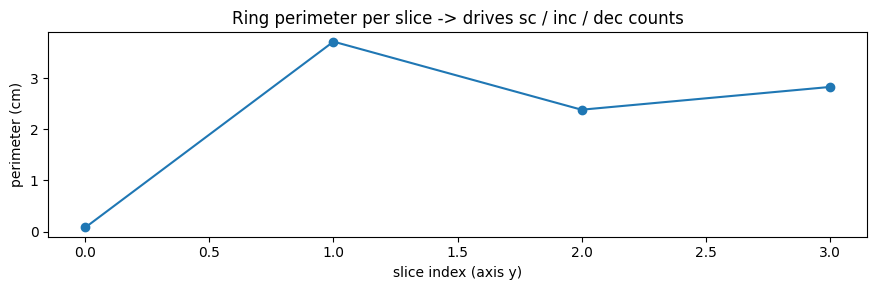

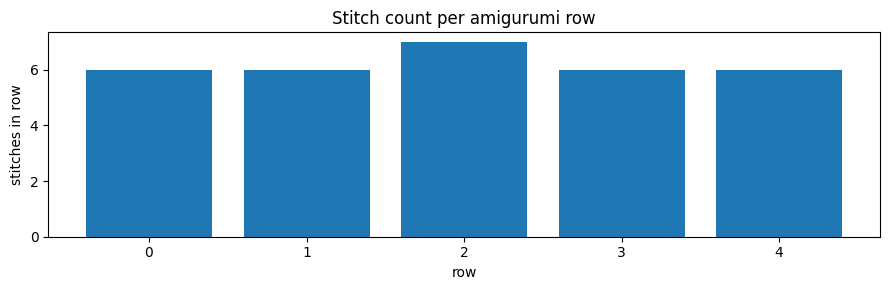

In [127]:
# Plot only when the 3D path actually produced data. When `trimesh` is
# missing we skip silently instead of blowing up.
if demo_3d.get("amigurumi_debug") and demo_3d["amigurumi_debug"].get("raw_perimeters_cm"):
    dbg = demo_3d["amigurumi_debug"]
    perims = dbg["raw_perimeters_cm"]

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(range(len(perims)), perims, marker="o")
    ax.set_xlabel(f"slice index (axis {dbg['axis']})")
    ax.set_ylabel("perimeter (cm)")
    ax.set_title("Ring perimeter per slice -> drives sc / inc / dec counts")
    plt.tight_layout(); plt.show()

    counts = [r["stitches"] for r in demo_3d["amigurumi_rows"]]
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.bar(range(len(counts)), counts)
    ax.set_xlabel("row"); ax.set_ylabel("stitches in row")
    ax.set_title("Stitch count per amigurumi row")
    plt.tight_layout(); plt.show()
else:
    print("(3D path skipped — install `trimesh` and re-run the imports cell "
          "to see the slicing plots.)")

## 6 - Comparison and caveats

| Criterion | 2D path | 3D path (multi-view) | 3D path (amigurumi slicer) |
|---|---|---|---|
| Input | prompt | prompt -> mesh | prompt -> mesh |
| Output artefacts | scheme PNG + JSON | per-view PNG + JSON | row-by-row instructions (`.txt`) |
| Best for | motifs, doilies, granny squares, tapestries | sweater panels, bag faces, anything laid flat | amigurumi, hats, bags, closed-surface toys |
| Handles non-convex shapes? | - | yes (but each view is a 2D silhouette only) | **only as a single segment** - see below |
| Gauge-aware? | no (image-only) | no | **yes** (`stitches_per_cm`, `stitch_height_cm`) |
| Dependencies | Gemini + YOLO | trimesh + YOLO | trimesh only |

### Known limitations

- **Router granularity.** The ModernBERT step only chooses 2D vs 3D. A
  useful future refinement is a three-way split: `flat_motif`, `garment`,
  `amigurumi_toy`. Garments tend to use row-by-row written patterns with
  shaping, not round-by-round; the slicer needs a different seam strategy
  for those.
- **Single-segment slicer.** `mesh_to_amigurumi` treats the whole object as
  one continuous tube. *AmiGo* segments at saddle points of the geodesic
  distance field so limbs/heads become separate pieces joined with
  join-as-you-go. That is the right upgrade for dolls, octopi, etc.
- **Gauge is user-supplied.** Real crochet gauge varies by yarn weight,
  hook size, and individual tension. Ask the user for gauge and feed it
  into `stitches_per_cm`.
- **Hunyuan3D queue times.** The HF Space is rate-limited. For production
  use a paid inference endpoint or self-hosted weights.

### Next steps

1. **AmiGo-style segmentation.** Compute a geodesic distance field from
   the seed point, find saddle points, and slice each resulting region
   independently. `libigl` or `potpourri3d` expose the SciPy/PyTorch
   solvers needed.
2. **Crochet DSL emission.** Translate amigurumi rows to the CrochetPARADE
   DSL (`crochet.dsl.convert`) so the same rendering stack works for both
   paths.
3. **Constrained LLM shaping.** Feed the classified output into a
   constrained small-model pass that rephrases bare operations into
   natural-language instructions ("Begin with a magic ring of 6 single
   crochets ...").
4. **Port autoknit.** CMU's knitout and autoknit compilers have open-source
   implementations that can be ported: the geometry work is identical; only
   the stitch alphabet differs.

### References

- Guo et al., *AmiGo: Computational Design of Amigurumi Crochet Patterns*, SIGGRAPH Asia 2022 - [arxiv 2211.01178](https://arxiv.org/abs/2211.01178)
- Popescu et al., *Representing Crochet with Stitch Meshes* - [ACM DL](https://dl.acm.org/doi/fullHtml/10.1145/3424630.3425409)
- [CrochetPARADE](https://www.crochetparade.org/) - DSL and platform for 2D/3D crochet.
- [Tencent Hunyuan3D-2 on HF](https://huggingface.co/spaces/tencent/Hunyuan3D-2) - open-weights text/image -> 3D.
- [TripoSR](https://huggingface.co/spaces/hansyan/perflow-triposr) - fast image -> 3D.
- [Moritz Laurer - ModernBERT zero-shot](https://huggingface.co/blog/Ihor/refreshing-zero-shot-classification) - zero-shot classification baseline.
- [LangChain router docs](https://docs.langchain.com/oss/python/langchain/multi-agent/router) - routing pattern.
- [trimesh section docs](https://trimesh.org/section.html) - mesh plane slicing.
- [Knitting Software Automatically Converts 3D Models into Machine-knit Stuffies](https://hackaday.com/2019/06/14/knitting-software-automatically-converts-3d-models-into-machine-knit-stuffies/) - prior art for knitted version.